# EmoExpress: Five-Model Emotion Classifier

This notebook trains and compares five multi-label emotion-classification models:

1. TF-IDF + Logistic Regression
2. TF-IDF + Linear SVM
3. Bi-LSTM
4. Fine-tuned DistilBERT
5. Pretrained RoBERTa

This notebook does **not** repeat data exploration or preprocessing.
It loads the processed files created by:

`00_Data_Exploration_and_Preprocessing.ipynb`

Required processed files:

- `data/processed/goemotions_train.csv`
- `data/processed/goemotions_validation.csv`
- `data/processed/goemotions_test.csv`
- `data/processed/emotion_label_mapping.json`

All models are evaluated using:

- `classification_report`
- Hamming loss

No threshold tuning is performed.


## Import libraries


In [1]:
from pathlib import Path
import ast
import gc
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import tensorflow as tf

from datasets import Dataset, DatasetDict

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, hamming_loss

warnings.filterwarnings("ignore")


In [2]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

Check if a GPU is avaiable

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


## Load the processed GoEmotions data


In [6]:
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
METRICS_DIR = OUTPUT_DIR / "metrics"
FIGURE_DIR = OUTPUT_DIR / "figures"

for directory in [
    MODEL_DIR,
    METRICS_DIR,
    FIGURE_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

# print("Project root:", PROJECT_ROOT)
# print(
#     "Processed data directory:",
#     PROCESSED_DATA_DIR
# )


### Load train, validation, and test CSV files


In [7]:
train_path = (
    PROCESSED_DATA_DIR
    / "goemotions_train.csv"
)

validation_path = (
    PROCESSED_DATA_DIR
    / "goemotions_validation.csv"
)

test_path = (
    PROCESSED_DATA_DIR
    / "goemotions_test.csv"
)

required_files = [
    train_path,
    validation_path,
    test_path,
]

missing_files = [
    file_path
    for file_path in required_files
    if not file_path.exists()
]

if missing_files:
    raise FileNotFoundError(
        "Run 00_Data_Exploration_and_Preprocessing.ipynb first. "
        f"Missing files: {missing_files}"
    )

train_df = pd.read_csv(train_path)
validation_df = pd.read_csv(validation_path)
test_df = pd.read_csv(test_path)

print("Training shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)


Training shape: (43410, 9)
Validation shape: (5426, 7)
Test shape: (5427, 7)


### Restore list columns saved as JSON strings


In [8]:
def parse_list_column(value):
    """Convert a saved list string back into a Python list."""

    if isinstance(value, list):
        return value

    if pd.isna(value):
        return []

    try:
        return json.loads(value)
    except (json.JSONDecodeError, TypeError):
        return ast.literal_eval(value)


list_columns = [
    "labels",
    "emotion_names",
    "label_vector",
]

for dataframe in [
    train_df,
    validation_df,
    test_df,
]:
    for column in list_columns:
        dataframe[column] = dataframe[column].apply(
            parse_list_column
        )


### Load the emotion label mapping


In [9]:
label_mapping_path = (
    PROCESSED_DATA_DIR
    / "emotion_label_mapping.json"
)

if not label_mapping_path.exists():
    raise FileNotFoundError(
        "Run 00_Data_Exploration_and_Preprocessing.ipynb first. "
        f"Missing file: {label_mapping_path}"
    )

with open(
    label_mapping_path,
    "r",
    encoding="utf-8",
) as file:
    label_mapping = json.load(file)

label_names = [
    label_mapping[str(index)]
    for index in range(len(label_mapping))
]

num_labels = len(label_names)

print("Number of labels:", num_labels)
print(label_names)


Number of labels: 28
['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


### Verify the processed data


In [10]:
display(
    train_df[
        [
            "text",
            "clean_text_ml",
            "emotion_names",
            "label_vector",
        ]
    ].head(3)
)

print(
    "Label-vector length:",
    len(train_df.iloc[0]["label_vector"])
)


,text,clean_text_ml,emotion_names,label_vector
0,My favourite food is anything I didn't have to...,my favourite food is anything i didn't have to...,[neutral],"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,"Now if he does off himself, everyone will thin...","now if he does off himself, everyone will thin...",[neutral],"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,WHY THE FUCK IS BAYLESS ISOING,why the fuck is bayless isoing,[anger],"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


Label-vector length: 28


### Prepare multi-label target arrays


In [11]:
y_train = np.asarray(
    train_df["label_vector"].tolist(),
    dtype=np.int8
)

y_validation = np.asarray(
    validation_df["label_vector"].tolist(),
    dtype=np.int8
)

y_test = np.asarray(
    test_df["label_vector"].tolist(),
    dtype=np.int8
)

print("y_train shape:", y_train.shape)
print(
    "y_validation shape:",
    y_validation.shape
)
print("y_test shape:", y_test.shape)
print(
    "Unique target values:",
    np.unique(y_train)
)


y_train shape: (43410, 28)
y_validation shape: (5426, 28)
y_test shape: (5427, 28)
Unique target values: [0 1]


### Rebuild a Hugging Face DatasetDict for transformer models

The original text and integer label IDs from the processed CSV files are
converted back into Hugging Face datasets. This allows DistilBERT and
RoBERTa to use the same train, validation, and test records as the other
models.


In [12]:
def dataframe_to_huggingface_dataset(dataframe):
    transformer_dataframe = dataframe[
        ["text", "labels"]
    ].copy()

    transformer_dataframe["labels"] = (
        transformer_dataframe["labels"].apply(list)
    )

    return Dataset.from_pandas(
        transformer_dataframe,
        preserve_index=False
    )


dataset = DatasetDict(
    {
        "train": dataframe_to_huggingface_dataset(
            train_df
        ),
        "validation": dataframe_to_huggingface_dataset(
            validation_df
        ),
        "test": dataframe_to_huggingface_dataset(
            test_df
        ),
    }
)

dataset


DatasetDict({
    train: Dataset({
        features: ['text', 'labels'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels'],
        num_rows: 5427
    })
})

## Data usage by model

- Logistic Regression and Linear SVM use `clean_text_ml`.
- Bi-LSTM, DistilBERT, and RoBERTa use the original `text`.
- Every model uses the same 28-dimensional `label_vector` targets.
- Data exploration, cleaning, and multi-hot encoding are performed only in Notebook 00.


## Shared evaluation function


In [30]:
def evaluate_multilabel_model(
    y_true,
    y_pred,
    model_name,
    target_names,
    training_time_seconds=None,
    inference_time_seconds=None,
):
    """
    Evaluate a multi-label model using classification_report
    and Hamming loss, then return the full summary row.
    """

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        zero_division=0,
        output_dict=True,
    )

    report_df = pd.DataFrame(
        report_dict
    ).transpose()

    model_hamming_loss = hamming_loss(
        y_true,
        y_pred,
    )

    print("=" * 100)
    print(model_name)
    print("=" * 100)

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=target_names,
            zero_division=0,
        )
    )

    print(
        f"Hamming Loss: "
        f"{model_hamming_loss:.6f}"
    )

    summary = {
        "model": model_name,

        "micro_precision": float(
            report_df.loc[
                "micro avg",
                "precision",
            ]
        ),

        "micro_recall": float(
            report_df.loc[
                "micro avg",
                "recall",
            ]
        ),

        "micro_f1": float(
            report_df.loc[
                "micro avg",
                "f1-score",
            ]
        ),

        "macro_precision": float(
            report_df.loc[
                "macro avg",
                "precision",
            ]
        ),

        "macro_recall": float(
            report_df.loc[
                "macro avg",
                "recall",
            ]
        ),

        "macro_f1": float(
            report_df.loc[
                "macro avg",
                "f1-score",
            ]
        ),

        "weighted_f1": float(
            report_df.loc[
                "weighted avg",
                "f1-score",
            ]
        ),

        "samples_f1": float(
            report_df.loc[
                "samples avg",
                "f1-score",
            ]
        ),

        "hamming_loss": float(
            model_hamming_loss
        ),

        "training_time_seconds": (
            float(training_time_seconds)
            if training_time_seconds is not None
            else np.nan
        ),

        "inference_time_seconds": (
            float(inference_time_seconds)
            if inference_time_seconds is not None
            else np.nan
        ),
    }

    return report_df, summary

Standardize existing results

In [68]:
def standardize_result_keys(result):
    """
    Convert old and new model-result dictionaries
    into one consistent lowercase format.
    """

    return {
        "model": result.get(
            "model",
            result.get("Model"),
        ),

        "micro_precision": result.get(
            "micro_precision",
            result.get("Micro Precision"),
        ),

        "micro_recall": result.get(
            "micro_recall",
            result.get("Micro Recall"),
        ),

        "micro_f1": result.get(
            "micro_f1",
            result.get("Micro F1"),
        ),

        "macro_precision": result.get(
            "macro_precision",
            result.get("Macro Precision", np.nan),
        ),

        "macro_recall": result.get(
            "macro_recall",
            result.get("Macro Recall", np.nan),
        ),

        "macro_f1": result.get(
            "macro_f1",
            result.get("Macro F1"),
        ),

        "weighted_f1": result.get(
            "weighted_f1",
            result.get("Weighted F1"),
        ),

        "samples_f1": result.get(
            "samples_f1",
            result.get("Samples F1", np.nan),
        ),

        "hamming_loss": result.get(
            "hamming_loss",
            result.get("Hamming Loss"),
        ),

        "training_time_seconds": result.get(
            "training_time_seconds",
            result.get(
                "Training Time Seconds",
                np.nan,
            ),
        ),

        "inference_time_seconds": result.get(
            "inference_time_seconds",
            result.get(
                "Inference Time Seconds",
                np.nan,
            ),
        ),
    }

Store every model’s results:

In [14]:
model_results = []

# Model 1: Logistic Regression

Use TF-IDF to convert text into numeric features.

In [15]:
tfidf = TfidfVectorizer(
    max_features=20_000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(
    train_df["clean_text_ml"].fillna("")
)

X_validation_tfidf = tfidf.transform(
    validation_df["clean_text_ml"].fillna("")
)

X_test_tfidf = tfidf.transform(
    test_df["clean_text_ml"].fillna("")
)

print(
    "Training TF-IDF shape:",
    X_train_tfidf.shape
)
print(
    "Validation TF-IDF shape:",
    X_validation_tfidf.shape
)
print(
    "Test TF-IDF shape:",
    X_test_tfidf.shape
)


Training TF-IDF shape: (43410, 20000)
Validation TF-IDF shape: (5426, 20000)
Test TF-IDF shape: (5427, 20000)


Train Logistic Regression

In [16]:
logistic_model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),
    n_jobs=-1
)

start_time = time.time()

logistic_model.fit(
    X_train_tfidf,
    y_train
)

logistic_training_time = time.time() - start_time

print(
    "Training time:",
    round(logistic_training_time, 2),
    "seconds"
)

Training time: 21.97 seconds


### Evaluate Logistic Regression

The model uses `predict()` with its default decision rule. No threshold tuning is performed.


### Logistic Regression classification report and Hamming loss


In [102]:
start_time = time.time()

logistic_test_predictions = logistic_model.predict(
    X_test_tfidf
)

logistic_inference_time = time.time() - start_time

(
    logistic_report_df,
    logistic_results
) = evaluate_multilabel_model(
    y_true=y_test,
    y_pred=logistic_test_predictions,
    model_name="TF-IDF + Logistic Regression",
    target_names=label_names
)

logistic_results[
    "training_time_seconds"
] = float(logistic_training_time)

logistic_results[
    "inference_time_seconds"
] = float(logistic_inference_time)

model_results.append(logistic_results)

display(logistic_report_df)
pd.DataFrame([logistic_results])


TF-IDF + Logistic Regression
                precision    recall  f1-score   support

    admiration       0.51      0.74      0.60       504
     amusement       0.72      0.89      0.79       264
         anger       0.31      0.60      0.41       198
     annoyance       0.20      0.50      0.29       320
      approval       0.19      0.49      0.27       351
        caring       0.17      0.45      0.24       135
     confusion       0.22      0.63      0.32       153
     curiosity       0.29      0.60      0.39       284
        desire       0.30      0.54      0.38        83
disappointment       0.14      0.38      0.20       151
   disapproval       0.21      0.57      0.31       267
       disgust       0.35      0.59      0.44       123
 embarrassment       0.23      0.27      0.25        37
    excitement       0.18      0.53      0.27       103
          fear       0.50      0.71      0.59        78
     gratitude       0.85      0.91      0.88       352
         grief    

,precision,recall,f1-score,support
admiration,0.509537,0.742063,0.604200,504.0
amusement,0.720000,0.886364,0.794567,264.0
anger,0.308094,0.595960,0.406196,198.0
annoyance,0.203283,0.503125,0.289568,320.0
approval,0.188043,0.492877,0.272227,351.0
caring,0.166213,0.451852,0.243028,135.0
confusion,0.215078,0.633987,0.321192,153.0
curiosity,0.288364,0.602113,0.389966,284.0
desire,0.298013,0.542169,0.384615,83.0
disappointment,0.140394,0.377483,0.204668,151.0


,model,micro_precision,micro_recall,micro_f1,macro_precision,macro_recall,macro_f1,weighted_f1,samples_f1,hamming_loss,training_time_seconds,inference_time_seconds
0,TF-IDF + Logistic Regression,0.373737,0.68352,0.483244,0.344401,0.593893,0.424438,0.517716,0.509727,0.060886,21.968082,0.016863


# Model 2: TF-IDF + Linear SVM

Train Linear SVM

In [18]:
svm_model = OneVsRestClassifier(
    LinearSVC(
        class_weight="balanced"
    ),
    n_jobs=-1
)

start_time = time.time()

svm_model.fit(
    X_train_tfidf,
    y_train
)

svm_training_time = time.time() - start_time

print(
    "Training time:",
    round(svm_training_time, 2),
    "seconds"
)

Training time: 6.25 seconds


### Evaluate Linear SVM

The model uses `predict()` with its default decision boundary of `0.0`. No threshold tuning is performed.


### Linear SVM classification report and Hamming loss


In [103]:
start_time = time.time()

svm_test_predictions = svm_model.predict(
    X_test_tfidf
)

svm_inference_time = time.time() - start_time

(
    svm_report_df,
    svm_results
) = evaluate_multilabel_model(
    y_true=y_test,
    y_pred=svm_test_predictions,
    model_name="TF-IDF + Linear SVM",
    target_names=label_names
)

svm_results[
    "training_time_seconds"
] = float(svm_training_time)

svm_results[
    "inference_time_seconds"
] = float(svm_inference_time)

model_results.append(svm_results)

display(svm_report_df)
pd.DataFrame([svm_results])


TF-IDF + Linear SVM
                precision    recall  f1-score   support

    admiration       0.51      0.64      0.57       504
     amusement       0.69      0.80      0.74       264
         anger       0.35      0.44      0.39       198
     annoyance       0.20      0.35      0.26       320
      approval       0.19      0.36      0.25       351
        caring       0.23      0.31      0.26       135
     confusion       0.24      0.41      0.30       153
     curiosity       0.31      0.46      0.37       284
        desire       0.41      0.35      0.38        83
disappointment       0.17      0.24      0.20       151
   disapproval       0.22      0.37      0.28       267
       disgust       0.39      0.43      0.41       123
 embarrassment       0.21      0.14      0.16        37
    excitement       0.20      0.36      0.25       103
          fear       0.57      0.59      0.58        78
     gratitude       0.87      0.91      0.89       352
         grief       0.50  

,precision,recall,f1-score,support
admiration,0.511111,0.638889,0.567901,504.0
amusement,0.690789,0.795455,0.739437,264.0
anger,0.350806,0.439394,0.390135,198.0
annoyance,0.203670,0.346875,0.256647,320.0
approval,0.190193,0.364672,0.250000,351.0
caring,0.227027,0.311111,0.262500,135.0
confusion,0.240458,0.411765,0.303614,153.0
curiosity,0.305361,0.461268,0.367461,284.0
desire,0.408451,0.349398,0.376623,83.0
disappointment,0.174757,0.238411,0.201681,151.0


,model,micro_precision,micro_recall,micro_f1,macro_precision,macro_recall,macro_f1,weighted_f1,samples_f1,hamming_loss,training_time_seconds,inference_time_seconds
0,TF-IDF + Linear SVM,0.423045,0.570232,0.485734,0.384208,0.442389,0.399355,0.497055,0.485247,0.050291,6.247898,0.137132


# Model 3: Bi-LSTM

## Model 3: Bi-LSTM

The Bi-LSTM uses the original `text` column loaded from the processed
CSV files. The traditional ML models use `clean_text_ml`, while the
sequence and transformer models preserve more of the original language.


In [20]:
MAX_WORDS = 30000
MAX_LENGTH = 128

keras_tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

keras_tokenizer.fit_on_texts(
    train_df["text"]
)

X_train_sequences = keras_tokenizer.texts_to_sequences(
    train_df["text"]
)

X_validation_sequences = keras_tokenizer.texts_to_sequences(
    validation_df["text"]
)

X_test_sequences = keras_tokenizer.texts_to_sequences(
    test_df["text"]
)

In [21]:
X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_validation_padded = pad_sequences(
    X_validation_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print(X_train_padded.shape)

(43410, 128)


Build the Bi-LSTM

In [22]:
bilstm_model = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128
    ),

    Bidirectional(
        LSTM(64)
    ),

    Dropout(0.4),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.3),

    Dense(
        num_labels,
        activation="sigmoid"
    )
])

bilstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="binary_accuracy"
        )
    ]
)

bilstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Train the Bi-LSTM

In [23]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

start_time = time.time()

history = bilstm_model.fit(
    X_train_padded,
    y_train,

    validation_data=(
        X_validation_padded,
        y_validation
    ),

    epochs=8,
    batch_size=64,

    callbacks=[early_stopping]
)

bilstm_training_time = time.time() - start_time

Epoch 1/8
679/679 ━━━━━━━━━━━━━━━━━━━━ 80s 106ms/step - binary_accuracy: 0.9546 - loss: 0.1602 - val_binary_accuracy: 0.9622 - val_loss: 0.1246
Epoch 2/8
679/679 ━━━━━━━━━━━━━━━━━━━━ 69s 102ms/step - binary_accuracy: 0.9641 - loss: 0.1209 - val_binary_accuracy: 0.9654 - val_loss: 0.1104
Epoch 3/8
679/679 ━━━━━━━━━━━━━━━━━━━━ 68s 101ms/step - binary_accuracy: 0.9678 - loss: 0.1044 - val_binary_accuracy: 0.9661 - val_loss: 0.1066
Epoch 4/8
679/679 ━━━━━━━━━━━━━━━━━━━━ 70s 104ms/step - binary_accuracy: 0.9704 - loss: 0.0918 - val_binary_accuracy: 0.9660 - val_loss: 0.1077
Epoch 5/8
679/679 ━━━━━━━━━━━━━━━━━━━━ 67s 98ms/step - binary_accuracy: 0.9730 - loss: 0.0810 - val_binary_accuracy: 0.9657 - val_loss: 0.1103


### Evaluate Bi-LSTM

Sigmoid probabilities are converted to binary predictions using the standard `0.50` threshold. No threshold tuning is performed.


### Bi-LSTM classification report and Hamming loss


In [104]:
start_time = time.time()

bilstm_test_probabilities = bilstm_model.predict(
    X_test_padded,
    verbose=1
)

bilstm_inference_time = time.time() - start_time

bilstm_test_predictions = (
    bilstm_test_probabilities >= 0.50
).astype(int)

(
    bilstm_report_df,
    bilstm_results
) = evaluate_multilabel_model(
    y_true=y_test,
    y_pred=bilstm_test_predictions,
    model_name="Bi-LSTM",
    target_names=label_names
)

bilstm_results[
    "training_time_seconds"
] = float(bilstm_training_time)

bilstm_results[
    "inference_time_seconds"
] = float(bilstm_inference_time)

model_results.append(bilstm_results)

display(bilstm_report_df)
pd.DataFrame([bilstm_results])


170/170 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step
Bi-LSTM
                precision    recall  f1-score   support

    admiration       0.64      0.51      0.57       504
     amusement       0.76      0.77      0.77       264
         anger       0.69      0.06      0.10       198
     annoyance       0.00      0.00      0.00       320
      approval       0.00      0.00      0.00       351
        caring       0.00      0.00      0.00       135
     confusion       0.00      0.00      0.00       153
     curiosity       0.33      0.01      0.03       284
        desire       0.78      0.08      0.15        83
disappointment       0.00      0.00      0.00       151
   disapproval       0.00      0.00      0.00       267
       disgust       0.00      0.00      0.00       123
 embarrassment       0.00      0.00      0.00        37
    excitement       0.00      0.00      0.00       103
          fear       0.00      0.00      0.00        78
     gratitude       0.96      0.87      0.91       3

,precision,recall,f1-score,support
admiration,0.641791,0.511905,0.569536,504.0
amusement,0.763158,0.768939,0.766038,264.0
anger,0.687500,0.055556,0.102804,198.0
annoyance,0.000000,0.000000,0.000000,320.0
approval,0.000000,0.000000,0.000000,351.0
caring,0.000000,0.000000,0.000000,135.0
confusion,0.000000,0.000000,0.000000,153.0
curiosity,0.333333,0.014085,0.027027,284.0
desire,0.777778,0.084337,0.152174,83.0
disappointment,0.000000,0.000000,0.000000,151.0


,model,micro_precision,micro_recall,micro_f1,macro_precision,macro_recall,macro_f1,weighted_f1,samples_f1,hamming_loss,training_time_seconds,inference_time_seconds
0,Bi-LSTM,0.673803,0.358034,0.467602,0.322011,0.179643,0.204775,0.375971,0.392568,0.033957,355.483362,4.526117


# Model 4: Fine-tuned DistilBERT

Clear memory from Bi-LSTM

In [38]:
import gc   
tf.keras.backend.clear_session()
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Device: cpu


Import libraries

In [39]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

Define model and label mappings

In [40]:
DISTILBERT_MODEL_NAME = "distilbert-base-uncased"

id2label = {
    index: emotion
    for index, emotion in enumerate(label_names)
}

label2id = {
    emotion: index
    for index, emotion in enumerate(label_names)
}

print(id2label)

{0: 'admiration', 1: 'amusement', 2: 'anger', 3: 'annoyance', 4: 'approval', 5: 'caring', 6: 'confusion', 7: 'curiosity', 8: 'desire', 9: 'disappointment', 10: 'disapproval', 11: 'disgust', 12: 'embarrassment', 13: 'excitement', 14: 'fear', 15: 'gratitude', 16: 'grief', 17: 'joy', 18: 'love', 19: 'nervousness', 20: 'optimism', 21: 'pride', 22: 'realization', 23: 'relief', 24: 'remorse', 25: 'sadness', 26: 'surprise', 27: 'neutral'}


Load the DistilBERT tokenizer

In [41]:
distilbert_tokenizer = AutoTokenizer.from_pretrained(
    DISTILBERT_MODEL_NAME
)

Tokenize and encode labels

Preprocessing function:
- Tokenize each text.
- Convert label IDs such as [2, 15] into a 28-position multi-hot vector.
- Store the vector as floating-point values for binary cross-entropy.

In [42]:
MAX_TRANSFORMER_LENGTH = 128


def tokenize_goemotions_batch(batch):
    tokenized_batch = distilbert_tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_TRANSFORMER_LENGTH
    )

    multi_hot_labels = []

    for example_labels in batch["labels"]:
        label_vector = [0.0] * num_labels

        for label_id in example_labels:
            label_vector[int(label_id)] = 1.0

        multi_hot_labels.append(label_vector)

    tokenized_batch["labels"] = multi_hot_labels

    return tokenized_batch

Apply it to all splits

In [43]:
distilbert_dataset = dataset.map(
    tokenize_goemotions_batch,
    batched=True,
    remove_columns=dataset["train"].column_names,
    desc="Tokenizing GoEmotions for DistilBERT"
)

distilbert_dataset

Tokenizing GoEmotions for DistilBERT:   0%|          | 0/43410 [00:00<?, ? examples/s]

Tokenizing GoEmotions for DistilBERT:   0%|          | 0/5426 [00:00<?, ? examples/s]

Tokenizing GoEmotions for DistilBERT:   0%|          | 0/5427 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5427
    })
})

In [44]:
print(distilbert_dataset["train"][0].keys())
print(distilbert_dataset["train"][0]["labels"])
print(
    "Number of values in label vector:",
    len(distilbert_dataset["train"][0]["labels"])
)

dict_keys(['labels', 'input_ids', 'token_type_ids', 'attention_mask'])
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
Number of values in label vector: 28


Create the padding collator. Dynamic padding pads each batch only to its longest sequence rather than padding every example to 128 tokens.

In [45]:
class MultiLabelDataCollator(DataCollatorWithPadding):
    def __call__(self, features):
        labels = [
            feature.pop("labels")
            for feature in features
        ]

        batch = super().__call__(features)

        batch["labels"] = torch.tensor(
            labels,
            dtype=torch.float32
        )

        return batch

In [46]:
distilbert_data_collator = MultiLabelDataCollator(
    tokenizer=distilbert_tokenizer,
    return_tensors="pt"
)

Load DistilBERT for multi-label classification

In [47]:
distilbert_model = (
    AutoModelForSequenceClassification.from_pretrained(
        DISTILBERT_MODEL_NAME,
        num_labels=num_labels,
        id2label=id2label,
        label2id=label2id,
        problem_type="multi_label_classification"
    )
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [48]:
print("Problem type:",distilbert_model.config.problem_type)
print("Number of output labels:",distilbert_model.config.num_labels)

Problem type: multi_label_classification
Number of output labels: 28


### Define the sigmoid conversion function


In [49]:
def sigmoid_numpy(logits):
    logits = np.clip(logits, -50, 50)
    return 1.0 / (1.0 + np.exp(-logits))


Configure training

In [50]:
DISTILBERT_OUTPUT_DIR = (
    MODEL_DIR
    / "distilbert-goemotions-checkpoints"
)

distilbert_training_args = TrainingArguments(
    output_dir=str(
        DISTILBERT_OUTPUT_DIR
    ),
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    save_total_limit=2,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=42,
    data_seed=42
)


Create the Trainer

In [51]:
distilbert_trainer = Trainer(
    model=distilbert_model,
    args=distilbert_training_args,
    train_dataset=distilbert_dataset["train"],
    eval_dataset=distilbert_dataset["validation"],
    processing_class=distilbert_tokenizer,
    data_collator=distilbert_data_collator,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)


Fine-tune DistilBERT

In [ ]:
start_time = time.time()

distilbert_train_output = distilbert_trainer.train()

distilbert_training_time = (time.time() - start_time)

print("DistilBERT training time:",round(distilbert_training_time, 2),"seconds")

Epoch,Training Loss,Validation Loss
1,0.089508,0.088529
2,0.082307,0.083468
3,0.074728,0.083494


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT training time: 16462.17 seconds


Plot training and validation loss

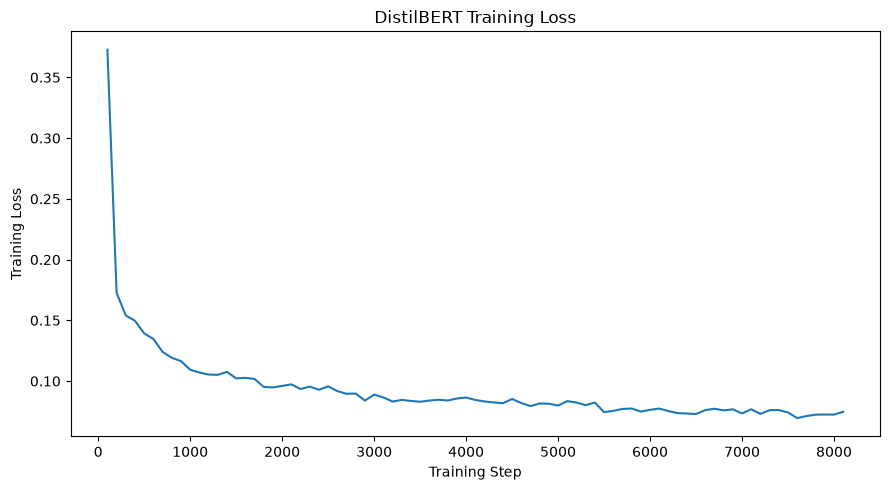

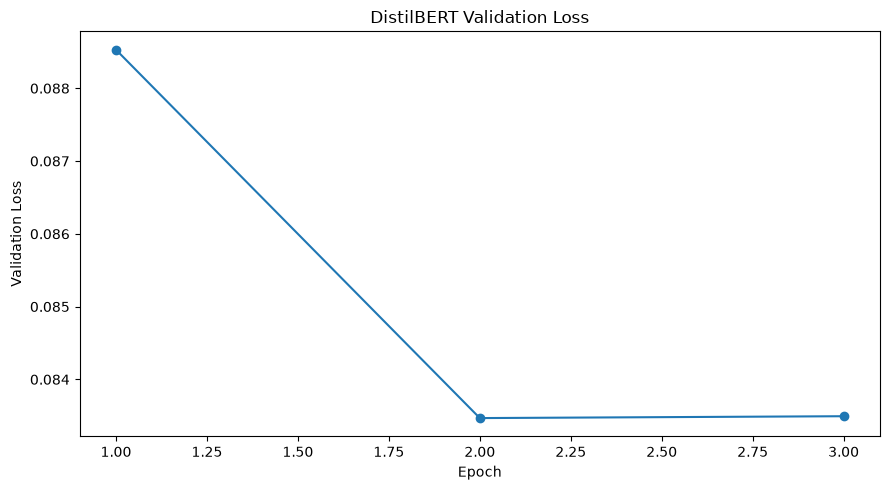

In [53]:
distilbert_log_history = pd.DataFrame(
    distilbert_trainer.state.log_history
)

distilbert_log_history.tail()
# Extract training loss:
train_loss_history = distilbert_log_history[
    distilbert_log_history["loss"].notna()
].copy()

validation_loss_history = distilbert_log_history[
    distilbert_log_history["eval_loss"].notna()
].copy()
# Plot training loss:
plt.figure(figsize=(9, 5))

plt.plot(
    train_loss_history["step"],
    train_loss_history["loss"]
)

plt.xlabel("Training Step")
plt.ylabel("Training Loss")
plt.title("DistilBERT Training Loss")
plt.tight_layout()
plt.show()
#Plot validation loss:
plt.figure(figsize=(9, 5))

plt.plot(
    validation_loss_history["epoch"],
    validation_loss_history["eval_loss"],
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("DistilBERT Validation Loss")
plt.tight_layout()
plt.show()

### Final DistilBERT evaluation uses the test set directly


### DistilBERT classification report and Hamming loss


In [54]:
start_time = time.time()

distilbert_test_output = distilbert_trainer.predict(
    distilbert_dataset["test"]
)

distilbert_inference_time = time.time() - start_time

print(
    "DistilBERT test inference time:",
    round(distilbert_inference_time, 2),
    "seconds"
)


DistilBERT test inference time: 112.43 seconds


In [106]:
distilbert_test_logits = distilbert_test_output.predictions

if isinstance(distilbert_test_logits, tuple):
    distilbert_test_logits = distilbert_test_logits[0]

distilbert_test_probabilities = sigmoid_numpy(
    distilbert_test_logits
)

distilbert_test_predictions = (
    distilbert_test_probabilities >= 0.50
).astype(int)

(
    distilbert_report_df,
    distilbert_results
) = evaluate_multilabel_model(
    y_true=y_test,
    y_pred=distilbert_test_predictions,
    model_name="Fine-tuned DistilBERT",
    target_names=label_names
)

distilbert_results[
    "training_time_seconds"
] = float(distilbert_training_time)

distilbert_results[
    "inference_time_seconds"
] = float(distilbert_inference_time)

display(distilbert_report_df)
pd.DataFrame([distilbert_results])


Fine-tuned DistilBERT
                precision    recall  f1-score   support

    admiration       0.75      0.61      0.67       504
     amusement       0.82      0.81      0.82       264
         anger       0.69      0.31      0.43       198
     annoyance       0.56      0.11      0.18       320
      approval       0.65      0.23      0.34       351
        caring       0.57      0.20      0.30       135
     confusion       0.62      0.29      0.39       153
     curiosity       0.55      0.43      0.48       284
        desire       0.67      0.29      0.40        83
disappointment       0.75      0.06      0.11       151
   disapproval       0.51      0.21      0.29       267
       disgust       0.75      0.31      0.44       123
 embarrassment       0.33      0.03      0.05        37
    excitement       0.84      0.20      0.33       103
          fear       0.77      0.56      0.65        78
     gratitude       0.94      0.89      0.92       352
         grief       0.00

,precision,recall,f1-score,support
admiration,0.750611,0.609127,0.672508,504.0
amusement,0.820611,0.814394,0.817490,264.0
anger,0.688889,0.313131,0.430556,198.0
annoyance,0.564516,0.109375,0.183246,320.0
approval,0.650407,0.227920,0.337553,351.0
caring,0.574468,0.200000,0.296703,135.0
confusion,0.619718,0.287582,0.392857,153.0
curiosity,0.547085,0.429577,0.481262,284.0
desire,0.666667,0.289157,0.403361,83.0
disappointment,0.750000,0.059603,0.110429,151.0


,model,micro_precision,micro_recall,micro_f1,macro_precision,macro_recall,macro_f1,weighted_f1,samples_f1,hamming_loss,training_time_seconds,inference_time_seconds
0,Fine-tuned DistilBERT,0.731362,0.45726,0.562707,0.58767,0.337913,0.39783,0.529436,0.495596,0.029601,16462.170869,112.429734


### Add DistilBERT to the model comparison


In [107]:
model_results = [
    standardize_result_keys(result)
    for result in model_results
]

In [108]:
model_results = [ result  for result in model_results  if result["model"] != "Fine-tuned DistilBERT"]

model_results.append(distilbert_results)

# pd.DataFrame(model_results)


Save Model 4

In [109]:
DISTILBERT_FINAL_PATH = (
    MODEL_DIR
    / "distilbert-goemotions-final"
)

distilbert_trainer.save_model(
    str(DISTILBERT_FINAL_PATH)
)

distilbert_tokenizer.save_pretrained(
    str(DISTILBERT_FINAL_PATH)
)

# print(
#     "DistilBERT model saved to:",
#     DISTILBERT_FINAL_PATH
# )


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('d:\\FullStack_Academic\\Final Capstone\\EmoExpress\\models\\distilbert-goemotions-final\\tokenizer_config.json',
 'd:\\FullStack_Academic\\Final Capstone\\EmoExpress\\models\\distilbert-goemotions-final\\tokenizer.json')

In [60]:
distilbert_config_data = {
    "model_name": DISTILBERT_MODEL_NAME,
    "prediction_threshold": 0.50,
    "max_length": MAX_TRANSFORMER_LENGTH,
    "label_names": label_names
}

config_path = (
    DISTILBERT_FINAL_PATH
    / "emoexpress_config.json"
)

with open(
    config_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        distilbert_config_data,
        file,
        indent=4
    )

# print(
#     "Saved DistilBERT configuration:",
#     config_path
# )


# Model 5: Pretrained RoBERTa

This model uses `SamLowe/roberta-base-go_emotions`, which is already trained for the 28 GoEmotions labels.

It is evaluated without additional fine-tuning and uses the standard sigmoid threshold of `0.50`.


### Load the pretrained tokenizer and model


In [75]:
PRETRAINED_ROBERTA_MODEL = "SamLowe/roberta-base-go_emotions"

roberta_tokenizer = AutoTokenizer.from_pretrained(
    PRETRAINED_ROBERTA_MODEL
)

roberta_model = AutoModelForSequenceClassification.from_pretrained(
    PRETRAINED_ROBERTA_MODEL
)

roberta_model.to(device)
roberta_model.eval()

print("Loaded:", PRETRAINED_ROBERTA_MODEL)
print("Number of output labels:", roberta_model.config.num_labels)


config.json:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded: SamLowe/roberta-base-go_emotions
Number of output labels: 28


### Tokenize the GoEmotions test set


In [85]:
# Create the RoBERTa test dataset from the processed dataframe instead of using the variable-length labels column.
roberta_test_df = test_df[
    [
        "text",
        "label_vector",
    ]
].copy()

roberta_test_df = roberta_test_df.rename(
    columns={
        "label_vector": "labels",
    }
)

roberta_test_dataset = Dataset.from_pandas(
    roberta_test_df,
    preserve_index=False,
)

print(roberta_test_dataset[0]["labels"])
print(len(roberta_test_dataset[0]["labels"]))

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
28


In [86]:
def tokenize_roberta_batch(batch):
    return roberta_tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_TRANSFORMER_LENGTH,
    )


roberta_test_dataset = roberta_test_dataset.map(
    tokenize_roberta_batch,
    batched=True,
)

roberta_test_dataset = (
    roberta_test_dataset.remove_columns(
        ["text"]
    )
)

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

In [110]:
roberta_data_collator = MultiLabelDataCollator(
    tokenizer=roberta_tokenizer,
    padding=True
)

roberta_training_args = TrainingArguments(
    output_dir=str(MODEL_DIR / "pretrained-roberta-evaluation"),
    per_device_eval_batch_size=32,
    report_to="none",
    fp16=torch.cuda.is_available()
)

roberta_trainer = Trainer(
    model=roberta_model,
    args=roberta_training_args,
    processing_class=roberta_tokenizer,
    data_collator=roberta_data_collator
)

start_time = time.time()

roberta_test_output = roberta_trainer.predict(
    roberta_test_dataset
)

roberta_inference_time = time.time() - start_time

roberta_test_logits = roberta_test_output.predictions

if isinstance(roberta_test_logits, tuple):
    roberta_test_logits = roberta_test_logits[0]

roberta_test_probabilities = sigmoid_numpy(
    roberta_test_logits
)

roberta_test_predictions = (
    roberta_test_probabilities >= 0.50
).astype(int)

(
    roberta_report_df,
    roberta_results
) = evaluate_multilabel_model(
    y_true=y_test,
    y_pred=roberta_test_predictions,
    model_name="Pretrained RoBERTa",
    target_names=label_names
)

roberta_results[
    "training_time_seconds"
] = 0.0

roberta_inference_start = time.time()

roberta_test_output = roberta_trainer.predict(
    roberta_test_dataset
)

roberta_inference_time = (
    time.time()
    - roberta_inference_start
)

roberta_results[
    "inference_time_seconds"
] = float(roberta_inference_time)

model_results.append(roberta_results)

display(roberta_report_df)
pd.DataFrame([roberta_results])


Pretrained RoBERTa
                precision    recall  f1-score   support

    admiration       0.72      0.67      0.70       504
     amusement       0.79      0.87      0.83       264
         anger       0.65      0.38      0.48       198
     annoyance       0.47      0.16      0.24       320
      approval       0.61      0.30      0.40       351
        caring       0.45      0.32      0.37       135
     confusion       0.50      0.43      0.46       153
     curiosity       0.54      0.36      0.43       284
        desire       0.63      0.41      0.50        83
disappointment       0.62      0.20      0.30       151
   disapproval       0.49      0.31      0.38       267
       disgust       0.71      0.33      0.45       123
 embarrassment       0.75      0.24      0.37        37
    excitement       0.60      0.34      0.43       103
          fear       0.76      0.60      0.67        78
     gratitude       0.96      0.88      0.92       352
         grief       0.00   

,precision,recall,f1-score,support
admiration,0.724947,0.674603,0.698869,504.0
amusement,0.790378,0.871212,0.828829,264.0
anger,0.652174,0.378788,0.479233,198.0
annoyance,0.472222,0.159375,0.238318,320.0
approval,0.609195,0.301994,0.403810,351.0
caring,0.447917,0.318519,0.372294,135.0
confusion,0.500000,0.431373,0.463158,153.0
curiosity,0.537234,0.355634,0.427966,284.0
desire,0.629630,0.409639,0.496350,83.0
disappointment,0.625000,0.198675,0.301508,151.0


,model,micro_precision,micro_recall,micro_f1,macro_precision,macro_recall,macro_f1,weighted_f1,samples_f1,hamming_loss,training_time_seconds,inference_time_seconds
0,Pretrained RoBERTa,0.684645,0.511455,0.585511,0.575237,0.396229,0.450315,0.56376,0.544401,0.03016,0.0,233.095955


# Compare All Five Models

The comparison uses values extracted from each model's classification report plus Hamming loss.

- Higher Micro F1, Macro F1, and Weighted F1 are better.
- Lower Hamming loss is better.


In [111]:
comparison_df = pd.DataFrame(model_results)

comparison_df = comparison_df.drop_duplicates(
    subset="model",
    keep="last"
)

comparison_df = comparison_df.sort_values(
    "micro_f1",
    ascending=False
).reset_index(drop=True)

comparison_df


,model,micro_precision,micro_recall,micro_f1,macro_precision,macro_recall,macro_f1,weighted_f1,samples_f1,hamming_loss,training_time_seconds,inference_time_seconds
0,Pretrained RoBERTa,0.684645,0.511455,0.585511,0.575237,0.396229,0.450315,0.563760,0.544401,0.030160,0.000000,233.095955
1,Fine-tuned DistilBERT,0.731362,0.457260,0.562707,0.587670,0.337913,0.397830,0.529436,0.495596,0.029601,16462.170869,112.429734
2,TF-IDF + Linear SVM,0.423045,0.570232,0.485734,0.384208,0.442389,0.399355,0.497055,0.485247,0.050291,6.247898,0.137132
3,TF-IDF + Logistic Regression,0.373737,0.683520,0.483244,0.344401,0.593893,0.424438,0.517716,0.509727,0.060886,21.968082,0.016863
4,Bi-LSTM,0.673803,0.358034,0.467602,0.322011,0.179643,0.204775,0.375971,0.392568,0.033957,355.483362,4.526117


### Compare Micro F1


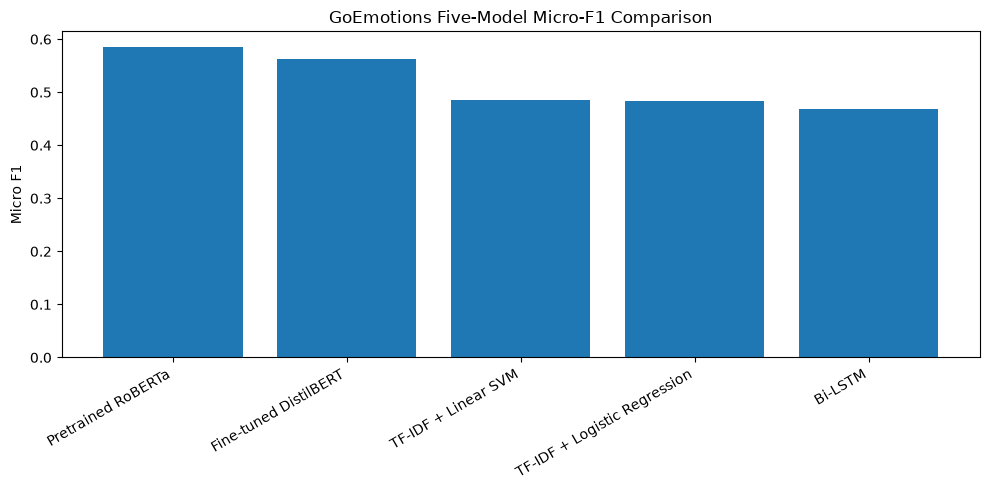

In [112]:
plt.figure(figsize=(10, 5))

plt.bar(
    comparison_df["model"],
    comparison_df["micro_f1"]
)

plt.ylabel("Micro F1")
plt.title("GoEmotions Five-Model Micro-F1 Comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### Compare Macro F1 and Hamming loss


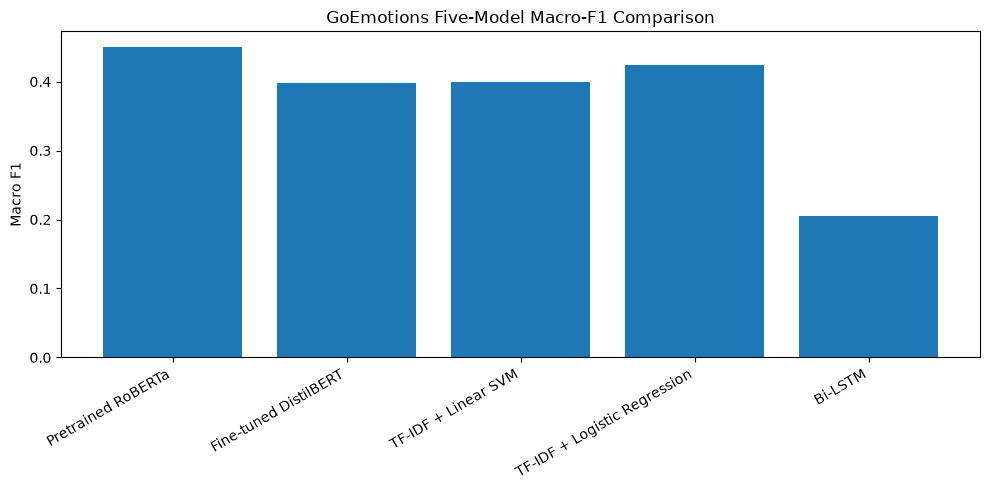

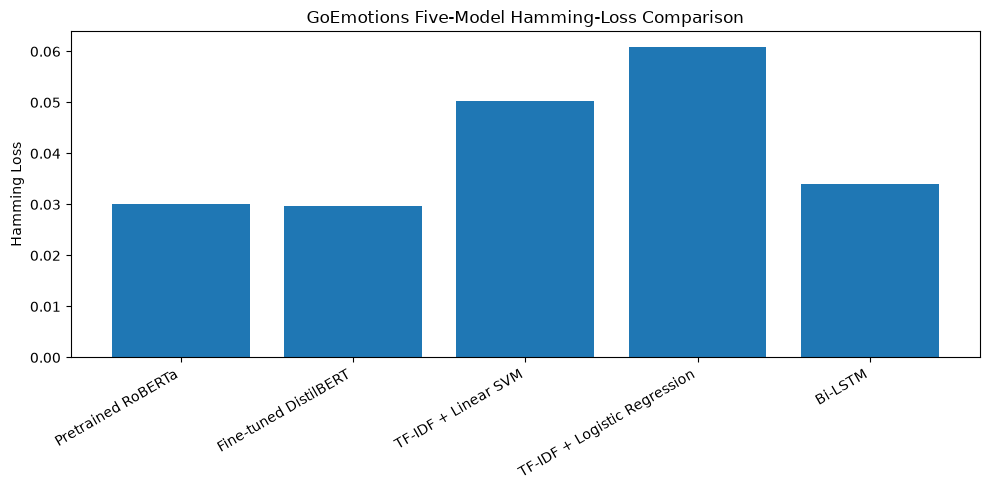

In [113]:
plt.figure(figsize=(10, 5))

plt.bar(
    comparison_df["model"],
    comparison_df["macro_f1"]
)

plt.ylabel("Macro F1")
plt.title("GoEmotions Five-Model Macro-F1 Comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))

plt.bar(
    comparison_df["model"],
    comparison_df["hamming_loss"]
)

plt.ylabel("Hamming Loss")
plt.title("GoEmotions Five-Model Hamming-Loss Comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


# Save Comparison Results

The consolidated table can be reused in the final report and presentation.


In [114]:
comparison_output_path = (
    METRICS_DIR
    / "five_model_comparison.csv"
)

comparison_df.to_csv(
    comparison_output_path,
    index=False
)

# print(
#     "Saved comparison to:",
#     comparison_output_path
# )


# Conclusion

Five models were implemented in one notebook and evaluated consistently using the classification report and Hamming loss. No validation-based threshold tuning was performed. Logistic Regression and Linear SVM used their built-in `predict()` behavior, while Bi-LSTM, DistilBERT, and RoBERTa used the standard sigmoid threshold of `0.50`.

Use Micro F1 as the main overall comparison metric, Macro F1 to assess performance across rare and common emotions equally, and Hamming loss to measure the proportion of individual label decisions that were incorrect.

The pretrained RoBERTa model achieved the best overall performance, obtaining the highest Micro F1 (0.586) and Macro F1 (0.450) while maintaining a low Hamming Loss (0.030). These results indicate that RoBERTa provided the best balance between overall prediction accuracy and performance across both frequent and infrequent emotion classes.

The fine-tuned DistilBERT model ranked second, achieving a Micro F1 of 0.563 and the lowest Hamming Loss (0.0296) among all models. However, it required significantly longer training time (approximately 4.6 hours) compared with the other approaches.

Among the traditional machine learning models, Linear SVM slightly outperformed Logistic Regression in terms of Micro F1 (0.486 vs. 0.483) and produced a lower Hamming Loss (0.050 vs. 0.061), while requiring only a few seconds for training and inference.

Although the Bi-LSTM model achieved high precision (0.674) and a relatively low Hamming Loss (0.034), its lower recall resulted in the lowest Micro F1 (0.468) among the five models. In addition, its training time was considerably longer than the traditional machine learning models without providing superior overall performance.

Overall, the results demonstrate that transformer-based models outperform both traditional machine learning and Bi-LSTM models for multi-label emotion classification on the GoEmotions dataset. While RoBERTa achieved the best predictive performance, DistilBERT offers a competitive alternative with a smaller model size. Linear SVM remains a strong baseline due to its fast training and inference, making it suitable for resource-constrained environments.
